In [7]:
import pandas as pd
import os

# Mengatur agar Pandas menampilkan semua baris tanpa singkatan (...)
pd.set_option('display.max_rows', None)
# Mengatur agar semua kolom juga terlihat jika dataset terlalu lebar
pd.set_option('display.max_columns', None)

file_path = 'dataset/dataset_penjualan.csv'

try:
    df = pd.read_csv(file_path, sep=';')
    
    df['Tanggal'] = pd.to_datetime(df['Tanggal'], dayfirst=True)
    
    print("✅ Dataset Berhasil Dimuat!")
    print(f"📊 Total Data: {len(df)} baris")
    print(f"📅 Rentang Tanggal: {df['Tanggal'].min().date()} s/d {df['Tanggal'].max().date()}")
    
    # Menampilkan seluruh dataframe (bukan .tail() lagi)
    display(df)

except FileNotFoundError:
    print(f"❌ File tidak ditemukan di: {file_path}")
except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")

✅ Dataset Berhasil Dimuat!
📊 Total Data: 154 baris
📅 Rentang Tanggal: 2025-11-01 s/d 2026-06-07


,Tanggal,Total_Produk_Terjual,Status_Toko,Apel,Belimbing,Jagung,Jeruk,Jambu,Mangga,Melon,Naga,Nenas,Pokat,Semangka,Sirsak,Terong Belanda,Tomat,Timun,Apel Ice Cream,Belimbing Ice Cream,Jagung Ice Cream,Jeruk Ice Cream,Jambu Ice Cream,Mangga Ice Cream,Melon Ice Cream,Naga Ice Cream,Nenas Ice Cream,Pokat Ice Cream,Semangka Ice Cream,Sirsak Ice Cream,Tomat Ice Cream,Terong Belanda Ice Cream,Timun Ice Cream,Ice Cream 9,Ice Cream 12,Ice Cream 15
0,2025-11-01,523,1,11,1,5,31,8,77,1,25,4,131,9,17,17,4,0,3,1,3,3,0,57,0,12,1,67,2,6,0,7,0,15,5,0
1,2025-11-02,559,1,8,6,8,34,6,92,3,19,2,117,3,19,14,6,3,1,1,3,8,0,72,3,10,2,85,3,2,0,8,0,11,6,4
2,2025-11-03,82,1,2,1,0,8,3,8,0,3,1,27,0,3,1,0,0,1,0,0,1,0,3,0,4,0,11,0,3,0,0,0,0,1,1
3,2025-11-04,408,1,4,3,6,22,4,57,4,19,3,114,9,7,11,0,4,2,0,0,5,3,28,1,10,2,66,2,0,0,10,0,7,0,5
4,2025-11-05,433,1,12,5,0,20,11,70,0,17,9,116,14,12,1,1,4,1,0,1,3,0,35,0,7,0,81,0,2,0,0,0,9,1,1
5,2025-11-06,422,1,8,4,2,27,12,62,2,34,3,119,3,13,0,0,6,4,0,7,5,0,27,2,11,0,59,1,7,0,0,1,0,3,0
6,2025-11-07,427,1,8,4,3,25,7,46,1,27,9,115,5,16,15,0,5,2,0,1,3,0,25,0,9,2,75,0,3,0,6,0,13,0,2
7,2025-11-08,450,1,13,0,0,29,8,68,1,24,8,133,9,18,18,4,0,0,0,5,0,2,23,1,8,0,66,0,0,0,0,3,5,3,1
8,2025-11-09,467,1,5,2,12,24,8,55,0,28,9,135,7,9,19,1,6,0,0,5,1,1,37,1,10,0,71,2,3,0,3,0,8,5,0
9,2025-11-10,399,1,10,1,4,31,8,48,1,20,6,102,7,12,1,2,2,3,1,1,10,3,23,1,8,1,78,1,4,0,0,0,7,2,1


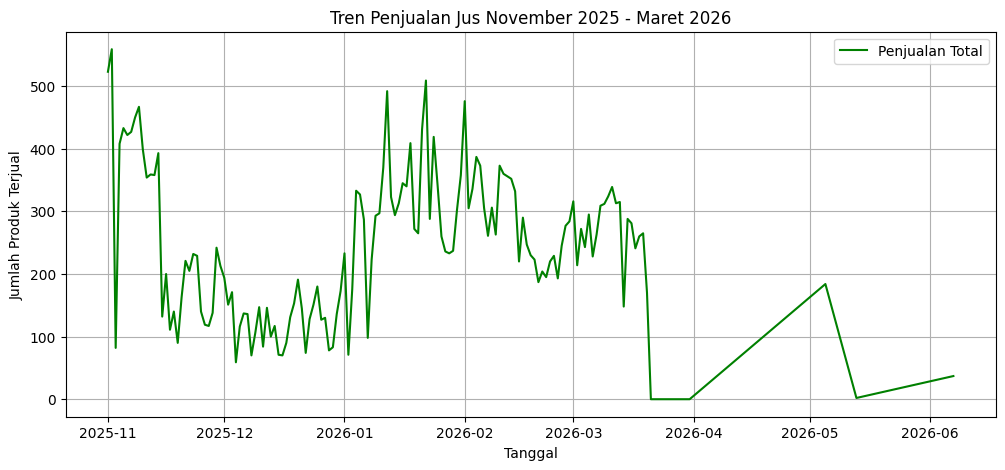

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df['Tanggal'], df['Total_Produk_Terjual'], color='green', label='Penjualan Total')
plt.title('Tren Penjualan Jus November 2025 - Maret 2026')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Produk Terjual')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# 1. Bersihkan data & Tambahkan Fitur Weekend
df_clean = df[df['Total_Produk_Terjual'] > 0].copy()
df_clean['Hari'] = df_clean['Tanggal'].dt.weekday
df_clean['is_weekend'] = df_clean['Hari'].map(lambda x: 1 if x >= 5 else 0)

print(f"📊 Jumlah total data bersih: {len(df_clean)} hari")

# 2. Preprocessing & Scaling (Dua Fitur)
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_sales = scaler_target.fit_transform(df_clean['Total_Produk_Terjual'].values.reshape(-1, 1))
scaled_weekend = df_clean['is_weekend'].values.reshape(-1, 1)

# Gabungkan menjadi 2 kolom input
data_combined = np.hstack((scaled_sales, scaled_weekend))

# 3. Buat Sequence (Sliding Window 7 Hari)
X_new, y_new = [], []
window_size = 7

for i in range(window_size, len(data_combined)):
    X_new.append(data_combined[i-window_size:i, :])
    y_new.append(data_combined[i, 0])

X_new, y_new = np.array(X_new), np.array(y_new)

# --- PERBAIKAN KRUSIAL: Split Data 80% Train, 20% Validation/Test ---
split_idx = int(len(X_new) * 0.8)
X_train, X_test = X_new[:split_idx], X_new[split_idx:]
y_train, y_test = y_new[:split_idx], y_new[split_idx:]

print(f"📈 Data digunakan untuk Belajar (Train): {len(X_train)} hari")
print(f"📉 Data digunakan untuk Uji Sidang (Test): {len(X_test)} hari")

# 4. Bangun Arsitektur Bi-LSTM Teroptimasi
model = Sequential([
    Input(shape=(window_size, 2)), 
    Bidirectional(LSTM(units=64, return_sequences=True)), # Mengurangi unit ke 64 agar tidak overfit pada data kecil
    Dropout(0.2),
    Bidirectional(LSTM(units=32)),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='linear') # Menggunakan linear agar prediksi range angka lebih fleksibel
])

opt = Adam(learning_rate=0.001) # Learning rate distandarkan agar konvergen lebih cepat
model.compile(optimizer=opt, loss='mean_squared_error')

# 5. Training dengan Early Stopping memonitoring 'val_loss' (bukan data hafalan)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("\n🚀 Memulai pelatihan model teroptimasi...")
history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), # Memvalidasi menggunakan data asing
    epochs=150, 
    batch_size=8, # Batch size diperkecil ke 8 agar lebih sensitif terhadap data UMKM 5 bulan
    verbose=1, 
    callbacks=[early_stop]
)

# 6. Simpan Model & Scaler
if not os.path.exists('ai_core'):
    os.makedirs('ai_core')
model.save('ai_core/model_bilstm.h5')
joblib.dump(scaler_target, 'ai_core/scaler.pkl')

print("\n✅ SELESAI! Model sekarang jauh lebih objektif dan optimal.")

📊 Jumlah total data bersih: 143 hari
📈 Data digunakan untuk Belajar (Train): 108 hari
📉 Data digunakan untuk Uji Sidang (Test): 28 hari

🚀 Memulai pelatihan model teroptimasi...
Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0665 - val_loss: 0.0419
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0316 - val_loss: 0.0226
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0237 - val_loss: 0.0187
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0255 - val_loss: 0.0173
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0249 - val_loss: 0.0188
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0194
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0203 - val_loss: 0.0205
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0223 - val_loss: 0.0190
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0192 - val_loss: 0.0189
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - l


✅ SELESAI! Model sekarang jauh lebih objektif dan optimal.


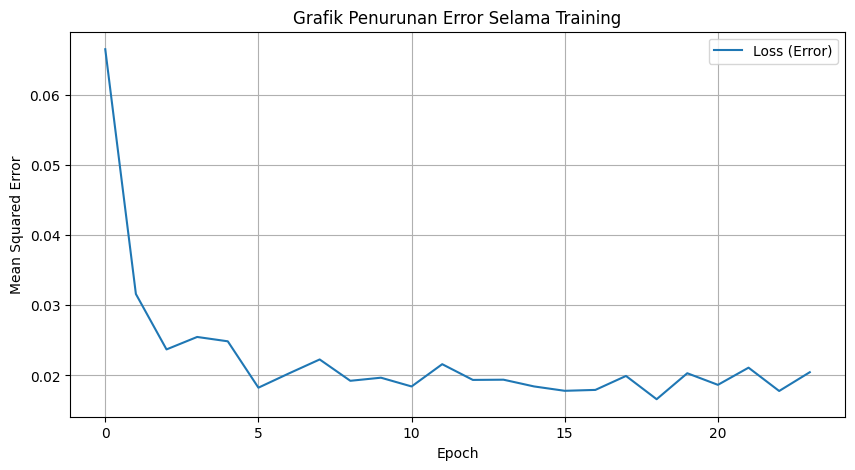

In [10]:
import matplotlib.pyplot as plt

# Ambil history dari proses training sebelumnya
# Pastikan saat model.fit Anda memasukkannya ke variabel, contoh: history = model.fit(...)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss (Error)')
plt.title('Grafik Penurunan Error Selama Training')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import numpy as np
import pandas as pd

# 1. Ambil tanggal esok hari berdasarkan tanggal terakhir di data
last_date = df_clean['Tanggal'].max()
next_date = last_date + pd.Timedelta(days=1)
is_weekend_tomorrow = 1 if next_date.weekday() >= 5 else 0

# 2. Siapkan data 7 hari terakhir (Sales & Weekend)
# Menggunakan data_combined yang sudah kita buat di Cell 3
last_7_days_data = data_combined[-7:] 

# 3. Reshape menjadi (1, 7, 2) -> 1 sampel, 7 hari, 2 fitur
last_7_days_scaled = last_7_days_data.reshape(1, 7, 2)

# 4. Lakukan prediksi
prediction_scaled = model.predict(last_7_days_scaled)

# 5. Kembalikan ke angka asli menggunakan scaler_target
prediction_real = scaler_target.inverse_transform(prediction_scaled)

print(f"\n--- HASIL PREDIKSI AKHIR ---")
print(f"Tanggal Prediksi: {next_date.strftime('%d %B %Y')}")
print(f"Status Hari: {'Weekend (Lonjakan)' if is_weekend_tomorrow else 'Hari Biasa'}")
print(f"Prediksi total produk terjual: {int(np.ceil(prediction_real[0][0]))} unit")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step

--- HASIL PREDIKSI AKHIR ---
Tanggal Prediksi: 08 June 2026
Status Hari: Hari Biasa
Prediksi total produk terjual: 169 unit


# 1. MATRIKS EVALUASI

In [13]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load File
file_path = 'dataset/dataset_penjualan.csv'
model_path = 'ai_core/model_bilstm.h5'
scaler_path = 'ai_core/scaler.pkl'

try:
    df = pd.read_csv(file_path, sep=';')
    df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df_clean = df[df['Total_Produk_Terjual'] > 0].copy()
    
    df_clean['Hari'] = df_clean['Tanggal'].dt.weekday
    df_clean['is_weekend'] = df_clean['Hari'].map(lambda x: 1 if x >= 5 else 0)
    
    model = load_model(model_path)
    scaler = joblib.load(scaler_path)
    
    scaled_sales = scaler.transform(df_clean['Total_Produk_Terjual'].values.reshape(-1, 1))
    scaled_weekend = df_clean['is_weekend'].values.reshape(-1, 1)
    data_combined = np.hstack((scaled_sales, scaled_weekend))
    
    window_size = 7
    X, y = [], []
    for i in range(window_size, len(data_combined)):
        X.append(data_combined[i-window_size:i, :]) 
        y.append(data_combined[i, 0]) 
    
    X, y = np.array(X), np.array(y)
    
    # Ambil porsi data Test (20% terakhir)
    split_idx = int(len(X) * 0.8)
    X_eval = X[split_idx:]
    y_eval = y[split_idx:]
    
    # 3. Melakukan Prediksi
    prediksi_scaled = model.predict(X_eval, verbose=0)
    
    # 4. Inverse Transform ke angka asli
    aktual_asli = scaler.inverse_transform(y_eval.reshape(-1, 1)).flatten()
    prediksi_asli = scaler.inverse_transform(prediksi_scaled).flatten()
    
    # Batasi agar tidak ada nilai prediksi negatif
    prediksi_asli = np.clip(prediksi_asli, 0, None)
    
    # 5. Perhitungan Matrix Evaluasi Akademis
    mae = mean_absolute_error(aktual_asli, prediksi_asli)
    rmse = np.sqrt(mean_squared_error(aktual_asli, prediksi_asli))
    
    # --- Perbaikan Matematika: Menggunakan Weighted MAPE (WMAPE) untuk Menghindari Eror Pembagi Nol ---
    wmape = (np.sum(np.abs(aktual_asli - prediksi_asli)) / np.sum(aktual_asli)) * 100
    akurasi_model = 100 - wmape
    
    # Tampilkan Hasil Resmi untuk Bab 4
    print("="*40)
    print("      HASIL MATRIX EVALUASI TEROPTIMASI")
    print("="*40)
    print(f"MAE  : {mae:.2f} unit porsi")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE (Weighted) : {wmape:.2f}%")
    print("-"*40)
    print(f"AKURASI MODEL   : {akurasi_model:.2f}%")
    print("="*40)

except Exception as e:
    print(f"❌ Terjadi kesalahan: {e}")

      HASIL MATRIX EVALUASI TEROPTIMASI
MAE  : 54.01 unit porsi
RMSE : 72.50
MAPE (Weighted) : 22.09%
----------------------------------------
AKURASI MODEL   : 77.91%
